$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.10

最大最小拉丁超立方设计（MmLHD）映射至维度为 $2, \dots, p-1$ 的子空间时投影效果较差。倘若试图改善最大最小拉丁超立方设计的投影特性，则子空间总数满足：$p+\binom{p}{2}+\dots+\binom{p}{p-1}=2^p-2$。当 $p$ 取值较大时，子空间数量十分庞大，致使基于 TRD 准则的优化计算量激增，难以实现求解。

另外，对于引入权重的 TRD，其准则变为：

$$
TRD_w(D)=\sum_{i=1}^{n}\sum_{j\neq i}\frac{1}{\{\sum_{k=1}^{p}w_k(x_{ik}-x_{jk})^2\}^\alpha}
$$

式中满足 $w_i \ge 0$（$i=1,\dots,p$），且 $\sum_{i=1}^{p}w_i = 1$。可是在设计阶段无法预知哪些变量是重要变量。解决该问题的一种方法是采用贝叶斯方法：先为权重向量 $\boldsymbol{w}=(w_1,\dots,w_{p-1})^\prime$ 设定先验分布，再在权重 $\boldsymbol{w}$ 的所有可行取值上对 $TRD_w(D)$ 求平均。

假设我们事先并不知晓各变量的重要程度，那么对权重 $\boldsymbol{w}$ 赋予均匀先验分布是合理的：

$$
f(\boldsymbol{w}) = (p - 1)!，\quad \boldsymbol{w} \in \mathcal{W} = \left\{\boldsymbol{w}:\boldsymbol{w} \ge 0,\sum_{i=1}^{p-1} w_i \le 1\right\}
\tag{4.22}
$$

于是可得：

$$
\int_{\mathcal{W}} TRD_w(D)f(\boldsymbol{w})d\boldsymbol{w} = \sum_{i=1}^n\sum_{j\ne i}\int_{\mathcal{W}} \frac{1}{\left\{\sum_{k=1}^p w_k(x_{ik}-x_{jk})^2\right\}^\alpha} f(\boldsymbol{w})d\boldsymbol{w}
$$

高维积分的计算成本通常较高，但可以注意到，当 $\alpha = p = 2$ 时，能够求得解析解：

$$
\int_0^1 \frac{1}{\left[w_1(x_{i1}-x_{j1})^2 + (1-w_1)(x_{i2}-x_{j2})^2\right]^2}dw_1 = \frac{1}{(x_{i1}-x_{j1})^2(x_{i2}-x_{j2})^2}
$$

借助数学归纳法即可证明下述结论。

> **定理 4.3** 若 $\alpha=p$，则在式 (4.22) 的先验分布条件下，
> $$\int_{\mathcal{W}}\frac{1}{\{\sum_{k=1}^{p}w_{k}(x_{ik}-x_{jk})^{2}\}^{\alpha}}f(\boldsymbol{w})d\boldsymbol{w}=\frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^{2}}$$

因此，设计准则为

$$
\min_D \sum_{i=1}^n \prod_{j \neq i}\frac{1}{\sum_{k=1}^p (x_{ik}-x_{jk})^2}
\tag{4.23}
$$

由于该准则能够最大化设计的投影能力，其被命名为最大投影（MaxPro）设计。该准则的计算复杂度并未高于式 (4.18) 中的截断随机设计（TRD）准则，仅是将分母中的求和运算替换为连乘运算。连乘项能够保证任意两个坐标互不相等，因此该准则可自动满足拉丁超立方设计的约束条件。

约瑟夫等人（2015）提出一种基于梯度的优化方法来构造极大投影（MaxPro）设计，式 (4.23) 中目标函数关于 $x_{rs}$ 的梯度表达式为：

$$
\frac{\partial}{\partial x_{rs}}\left\{\sum_{i=1}^{n}\sum_{j\neq i} \frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{jk})^2}\right\}=4\sum_{i\neq r} \frac{1}{\prod_{k=1}^{p}(x_{ik}-x_{rk})^2} \cdot \frac{1}{(x_{is}-x_{rs})}
$$

但该目标函数存在大量局部最优解，想要求得全局最优解就需要设置大量随机初始点。为避免多次随机初始化寻优，可采用模拟退火算法先构造极大投影拉丁超立方设计（MaxPro LHD），再开展梯度优化。R 程序包 SFDesign 沿用此思路，并在模拟退火阶段结束后额外增加一步确定性优化。维度 $p=2$、样本量分别为 7 和 20 的极大投影设计结果如图 4.10 所示。可以观察到这类设计能够很好地填充整个空间，同时具备拉丁超立方结构；但各坐标轴上的采样点不再像普通拉丁超立方设计那样均匀分布。样本点会向区域边界靠拢，不过聚拢程度低于图 4.9 中切比雪夫变换的效果。

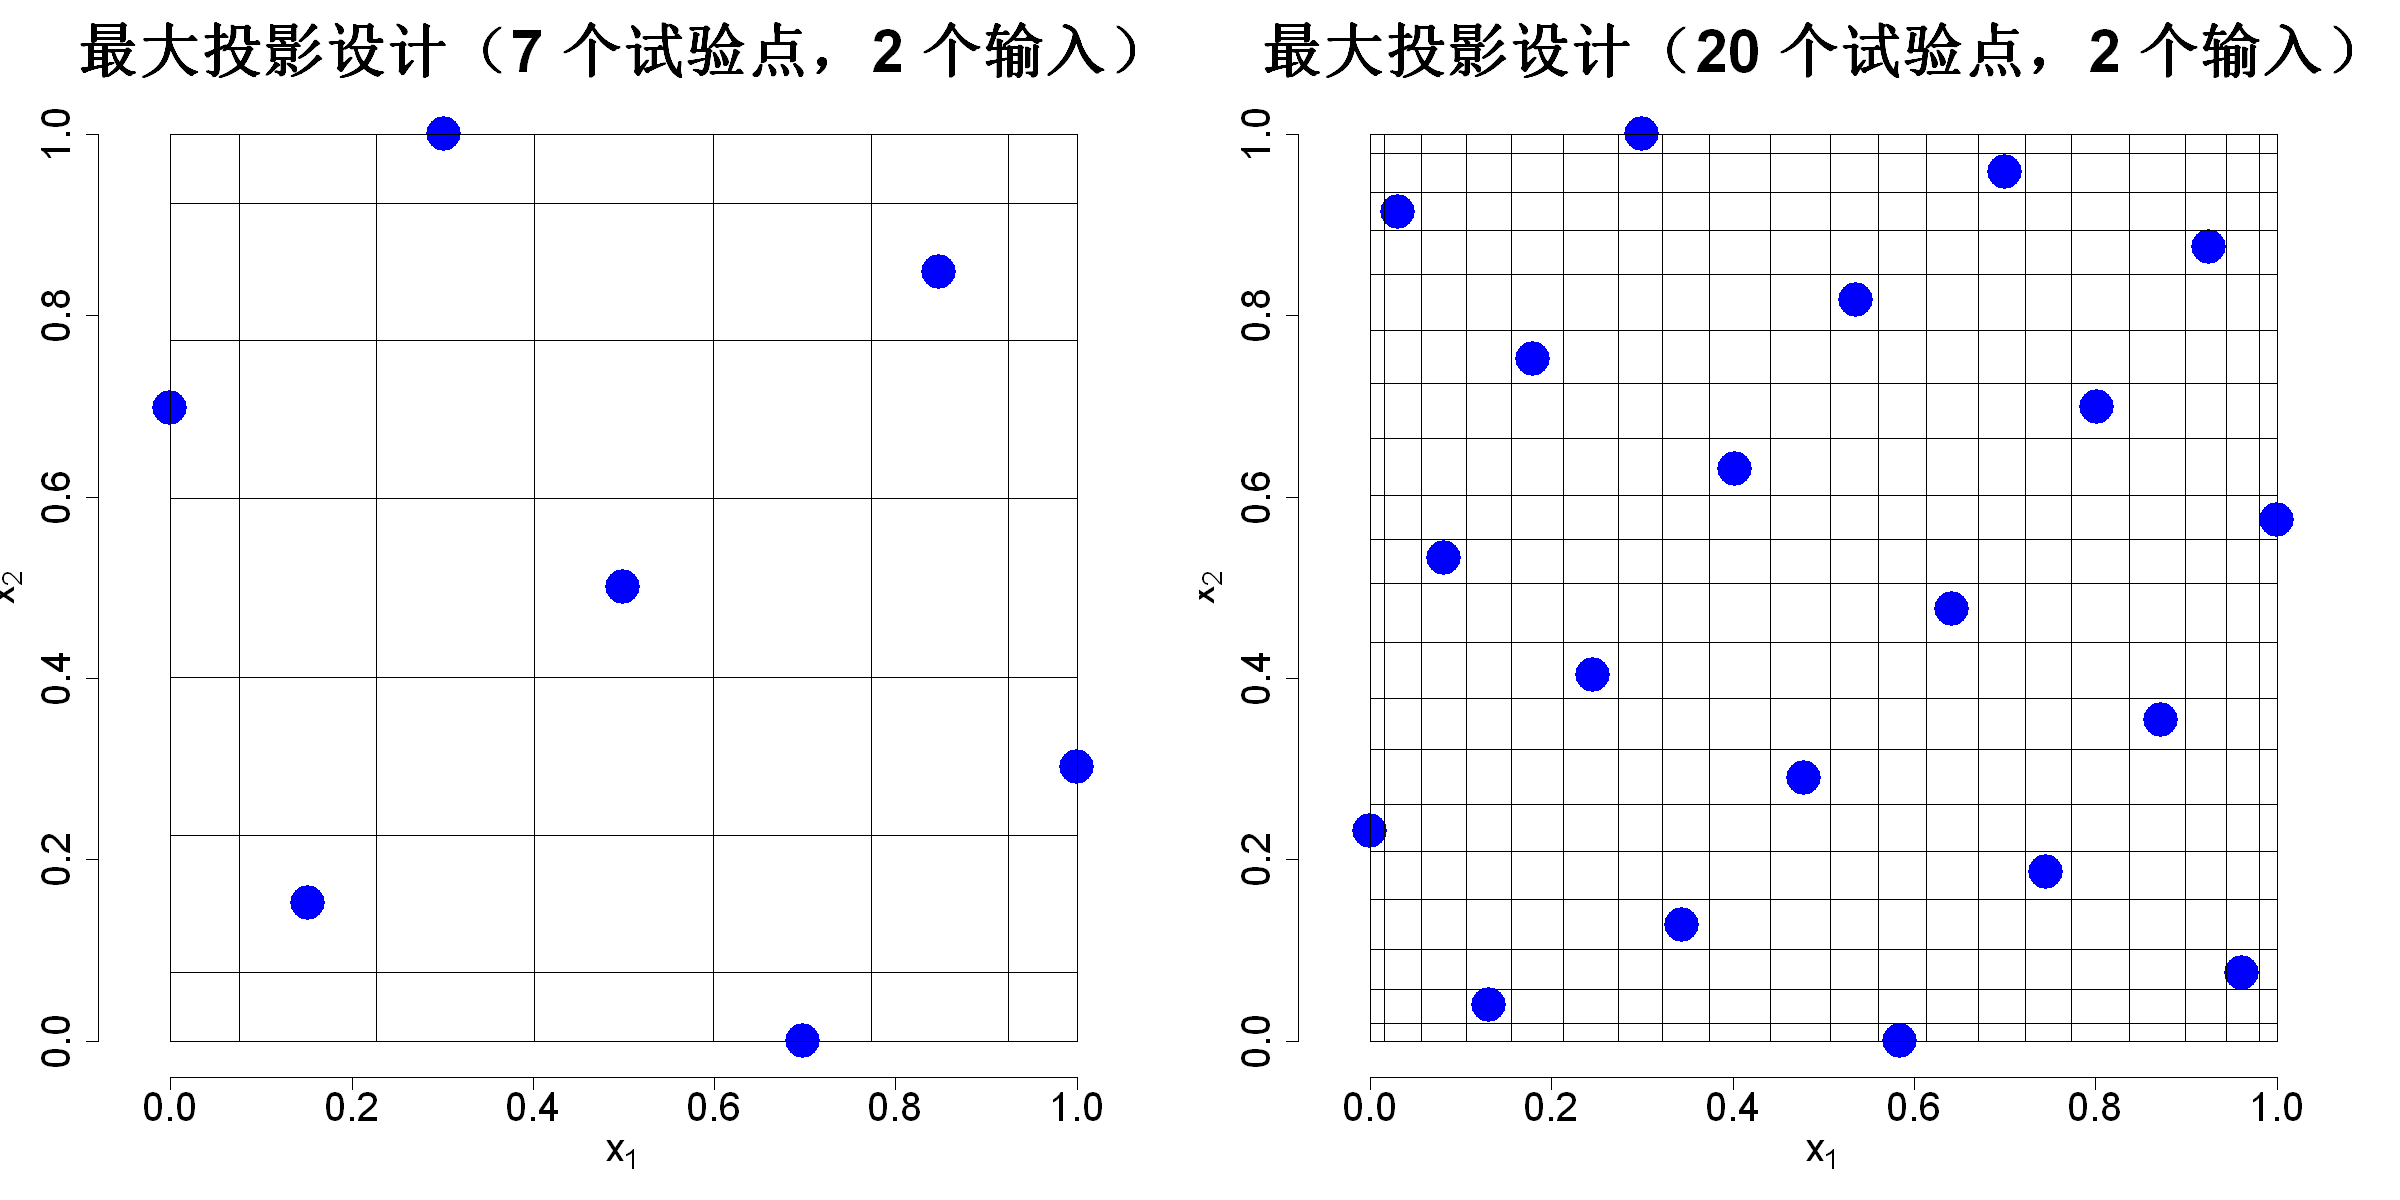

In [2]:
if(!dir.exists("data"))dir.create("data")
if(!file.exists("data/4.10-D1.csv")||!file.exists("data/4.10-D2.csv")||!file.exists("data/4.10-para.csv")){
  p=2;n1=7
  set.seed(1)
  library(SFDesign)
  D1=maxpro.optim(maxproLHD(n1,p)$design)$design # 7x2
  n2=20
  D2=maxpro.optim(maxproLHD(n2,p)$design)$design # 20x2
  write.csv(data.frame(D1=D1),"data/4.10-D1.csv",row.names=FALSE)
  write.csv(data.frame(D2=D2),"data/4.10-D2.csv",row.names=FALSE)
  write.csv(data.frame(n1=n1,n2=n2),"data/4.10-para.csv",row.names=FALSE)
}

df_D1=read.csv("data/4.10-D1.csv")
D1=as.matrix(df_D1[,paste0("D1.",1:2)])
df_D2=read.csv("data/4.10-D2.csv")
D2=as.matrix(df_D2[,paste0("D2.",1:2)])
para=read.csv("data/4.10-para.csv")
n1=para$n1;n2=para$n2

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(D1,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计（7 个试验点，2 个输入）",cex.main=3,asp=1)
d11=sort(D1[,1])
l11=c(0,(d11[-1]+d11[-n1])/2,1)
d12=sort(D1[,2])
l12=c(0,(d12[-1]+d12[-n1])/2,1)
for(i in 1:(n1+1)){
segments(l11[i],0,l11[i],1)
segments(0,l12[i],1,l12[i])
}
plot(D2,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计（20 个试验点，2 个输入）",cex.main=3,asp=1)
d21=sort(D2[,1])
l21=c(0,(d21[-1]+d21[-n2])/2,1)
d22=sort(D2[,2])
l22=c(0,(d22[-1]+d22[-n2])/2,1)
for(i in 1:(n2+1)){
segments(l21[i],0,l21[i],1)
segments(0,l22[i],1,l22[i])
}

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$